# Runtime
- 运行时上下文,仅对当前调用有效
- `StateGraph(context_schema=UserContext)`指定上下文类型
- `graph.invoke(context=UserContext(...))` 调用时，传入上下文内容
- 在节点中，通过`runtime: Runtime[UserContext]`和`runtime.context`获取上下文对象`UserContext`

2026-08-13 14:00:18.696 | INFO     | __main__:llm_node:36 - 当前用户: Alice, 会员等级: VIP


============================== 第一次调用：VIP用户 ==============================


2026-08-13 14:00:22.211 | WARNING  | __main__:llm_node:43 - 运行时上下文为空，使用默认风格


output: 尊敬的Alice，您好！非常荣幸能为您服务。🌟

为了给您提供最精准、最划算的优惠信息，能否麻烦您告知一下，您近期比较关注哪一类的产品或服务呢？（例如：数码电子、时尚服饰、家居生活，或是特定的品牌活动？）

一旦您提供具体方向，我将立刻为您筛选当前最高性价比的专属折扣、限时秒杀以及会员叠加福利，确保您不错过任何一次省钱良机！期待您的回复，我随时待命为您查询。😊

🎖️VIP专属服务

============================== 第二次调用：不传上下文 ==============================
output: 您好！很高兴为您服务。😊

请问您具体关注的是哪类产品呢？（例如：服饰、数码、美妆或家居等）

如果您能告诉我具体的**品类**或**品牌**，我可以更精准地为您查询最新上架的好物哦！


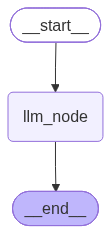

In [1]:
from dataclasses import dataclass
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.runtime import Runtime
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from loguru import logger

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 1. 定义运行时上下文类型
@dataclass
class UserContext:
    username: str
    membership_level: str  # "普通用户" / "VIP"

# 2. 定义图状态
class OverAllState(MessagesState):
    user_input: str
    output: str

# 3. 定义节点：通过 runtime.context 访问运行时上下文
def llm_node(state: OverAllState, runtime: Runtime[UserContext]) -> OverAllState:
    runtime_context = runtime.context

    if runtime_context:
        username = runtime_context.username
        level = runtime_context.membership_level
        logger.info(f"当前用户: {username}, 会员等级: {level}")

        if level == "VIP":
            system_prompt = f"你是高级客服助理。当前VIP用户是{username}，请使用尊称'您'，语气热情周到，回复末尾加上'🎖️VIP专属服务'。"
        else:
            system_prompt = f"你是普通客服助理。当前用户是{username}，请友好简洁地回复。"
    else:
        logger.warning("运行时上下文为空，使用默认风格")
        system_prompt = "你是客服助理，请友好简洁地回复。"

    user_input = state["user_input"]
    messages = state.get("messages", [])
    response = model.invoke(
        [HumanMessage(content=system_prompt)] +
        messages +
        [HumanMessage(content=user_input)]
    )

    return {
        "messages": [response],
        "output": response.content
    }

# 4. 构建图，传入 context_schema
builder = StateGraph(state_schema=OverAllState, context_schema=UserContext)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

graph = builder.compile()

# === 第一次调用：传入运行时上下文（VIP用户） ===
print("=" * 30, "第一次调用：VIP用户", "=" * 30)
config = {"configurable": {"thread_id": "demo-7.3"}}
res = graph.invoke(
    {"user_input": "你好，帮我查一下最近有什么优惠活动"},
    config=config,
    context=UserContext(username="Alice", membership_level="VIP")
)

print(f"output: {res['output']}")
print()

# === 第二次调用：不传运行时上下文 ===
print("=" * 30, "第二次调用：不传上下文", "=" * 30)
res2 = graph.invoke(
    {"user_input": "再帮我看看有没有新品"},
    config=config
)

print(f"output: {res2['output']}")

from IPython.display import display
display(graph)